# Cvičenie 2
Farebné priestory a ich aplikácie

Knižnice: NumPy + Matplotlib + Scikit-image

3 úlohy + 1 bonus

print(image.dtype, image.min(), image.max()) - zistenie typu a min/max hodnoty matice obrázku

Kód komentujte slovne pre vaše potreby.

**Pre pridelenie bodov vaše riešenie musíte vedieť jednoducho odprezentovať a rozumieť každej jeho časti.**

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import skimage as sk

### Úloha 1
Detekcia a vizualizácia preexpozície (clipping)

Zostrojte RGB histogram preexponovaného obrázka

Bez cyklu zistite, ktoré pixely majú v jednotlivých kanáloch (R, G, B) dosiahnutú maximálnu hodnotu (255) a vytvorte vizualizáciu, kde:

- len R clipped → červená
- len G clipped → zelená
- len B clipped → modrá
- všetky tri clipped → biela

Zobrazte pôvodný obrázok, jeho histogram a výsledný obrázok vedľa seba.

Pre RGB histogram doplnte správny kanál z ktorého sa má histogram vytvoriť.

Bez cyklu = boolean masky + indexovanie:

maska = matica[a,b,c] > 10
- ak je prvok matice na mieste a b c väčší ako 10, na prvku matice maska bude boolean hodnota 1

Bonus: čo ak sú clipped napríklad len R a G naraz?

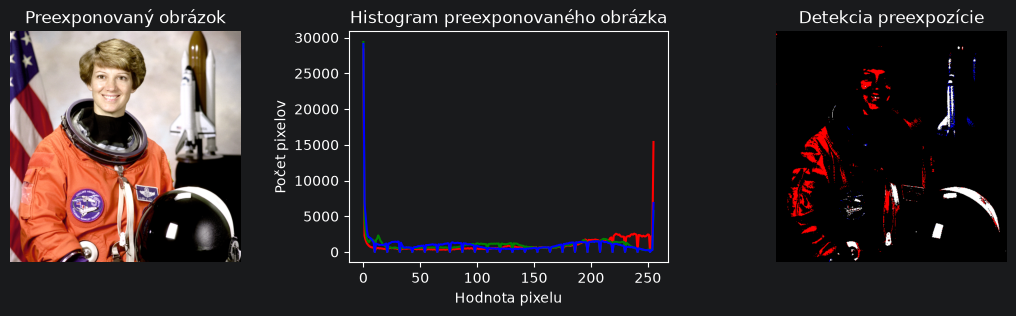

In [2]:
img_oe = sk.data.astronaut().astype(int)
img_final = np.zeros(np.shape(img_oe)).astype(int)
img_oe = np.minimum(img_oe *1.1, 255)

# HERE

# 1. Vytvorenie boolean masiek pre každý kanál
r_clip = img_oe[:, :, 0] == 255
g_clip = img_oe[:, :, 1] == 255
b_clip = img_oe[:, :, 2] == 255

# 2. Kombinácie masiek
only_r = r_clip & ~g_clip & ~b_clip
only_g = ~r_clip & g_clip & ~b_clip
only_b = ~r_clip & ~g_clip & b_clip
all_three = r_clip & g_clip & b_clip

# 3. Priradenie farieb do výsledného obrázka
img_final[only_r] = [255, 0, 0]
img_final[only_g] = [0, 255, 0]
img_final[only_b] = [0, 0, 255]
img_final[all_three] = [255, 255, 255]

# vykreslenie
fig, axs = plt.subplots(1, 3, figsize=(14, 3))
axs[0].imshow(img_oe.astype(np.uint8)); axs[0].set_title("Preexponovaný obrázok"); axs[0].axis("off")

# rgb histogram preexponovaného obrázka
colors = ("red", "green", "blue")
for channel_id, color in enumerate(colors):
    histogram, bin_edges = np.histogram(img_oe[:, :, channel_id] , bins=256, range=(0, 256))
    axs[1].plot(bin_edges[0:-1], histogram, color=color); axs[1].set_title("Histogram preexponovaného obrázka")
    axs[1].set_xlabel("Hodnota pixelu"); axs[1].set_ylabel("Počet pixelov")

axs[2].imshow(img_final.astype(np.uint8)); axs[2].set_title("Detekcia preexpozície"); axs[2].axis("off")
plt.axis("off")
plt.show()


### Úloha 2

Syntetický obrázok img preveďte do šedotónového zobrazenia pomocou:
1. funkcie sk.color.rgb2gray
2. Y = 0.2125 R + 0.7154 G + 0.0721 B
3. Y = (R+G+B)/3

Na akú farbu je oko najviac citlivé?

Aký je numerický rozdiel medzi implementáciami? (np.linalg.norm() - aká je toto norma?)

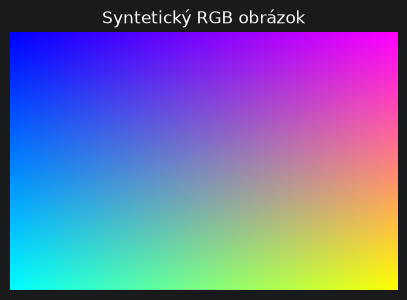

In [3]:
h, w = 200, 300
x = np.linspace(0, 1, w)
y = np.linspace(0, 1, h)
xx, yy = np.meshgrid(x, y)
R = xx
G = yy
B = 1 - xx*yy
img = (np.stack([R, G, B], axis=-1))
plt.figure(figsize=(5, 4))
plt.imshow(img)
plt.title("Syntetický RGB obrázok")
plt.axis("off")
plt.show()

Numerický rozdiel medzi metódami 1 a 2: 7.492296197433163e-15
Numerický rozdiel medzi metódami 1 a 3: 40.15886118649994
Numerický rozdiel medzi metódami 2 a 3: 40.15886118649994


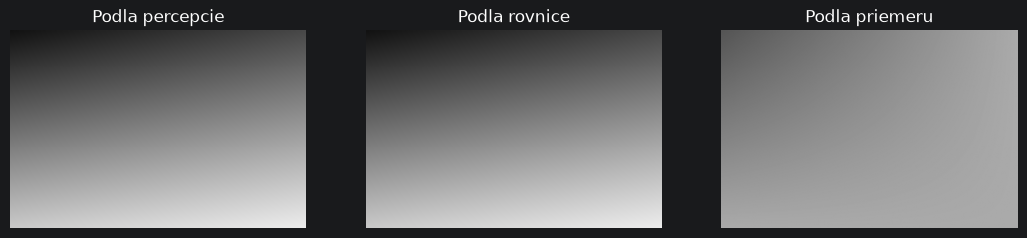

In [8]:
# HERE
img_gray1 = sk.color.rgb2gray (img)
img_gray2 = 0.2125 * img[:, :, 0] + 0.7154 * img[:, :, 1] + 0.0721 * img[:, :, 2]
img_gray3 = (img[:, :, 0] + img[:, :, 1] + img[:, :, 2]) / 3

difference1 = np.linalg.norm(img_gray1 - img_gray2)
print("Numerický rozdiel medzi metódami 1 a 2:", difference1)
difference2 = np.linalg.norm(img_gray1 - img_gray3)
print("Numerický rozdiel medzi metódami 1 a 3:", difference2)
difference3 = np.linalg.norm(img_gray2 - img_gray3)
print("Numerický rozdiel medzi metódami 2 a 3:", difference3)

fig, axs = plt.subplots(1, 3, figsize=(13, 4))
axs[0].imshow(img_gray1, cmap=plt.cm.gray, vmin=0, vmax=1); axs[0].set_title("Podla percepcie"); axs[0].axis("off")
axs[1].imshow(img_gray2, cmap=plt.cm.gray, vmin=0, vmax=1); axs[1].set_title("Podla rovnice"); axs[1].axis("off")
axs[2].imshow(img_gray3, cmap=plt.cm.gray, vmin=0, vmax=1); axs[2].set_title("Podla priemeru"); axs[2].axis("off")
plt.show()

### Úloha 3
Zvýšte fotke jas konverziou do pristoru HSV a Lab, a vykreslite histogram pre pôvodnú, HSV a Lab verziu.
Výsledok zobrazte ako na ukážke.

Zvýšenie jasu škálovaním príslušného kanála: napr. image[:,:,?]*1.2.

Hodnotový rozsah kanálov:

- HSV: všetky tri kanály v [0, 1]
- LAB: L v [0, 100], a a b typicky v [-128, 127]
- RGB (späť z hsv2rgb, lab2rgb): [0, 1]

Použite *sk.color.rgb2lab* a *sk.color.rgb2hsv*.

Príkaz pre histogram: axs[0,1].hist(obrazok, bins, histtype='step', color='black');

Nápoveda: image.ravel() spraví z obrázku 1D vektor pre histogram.

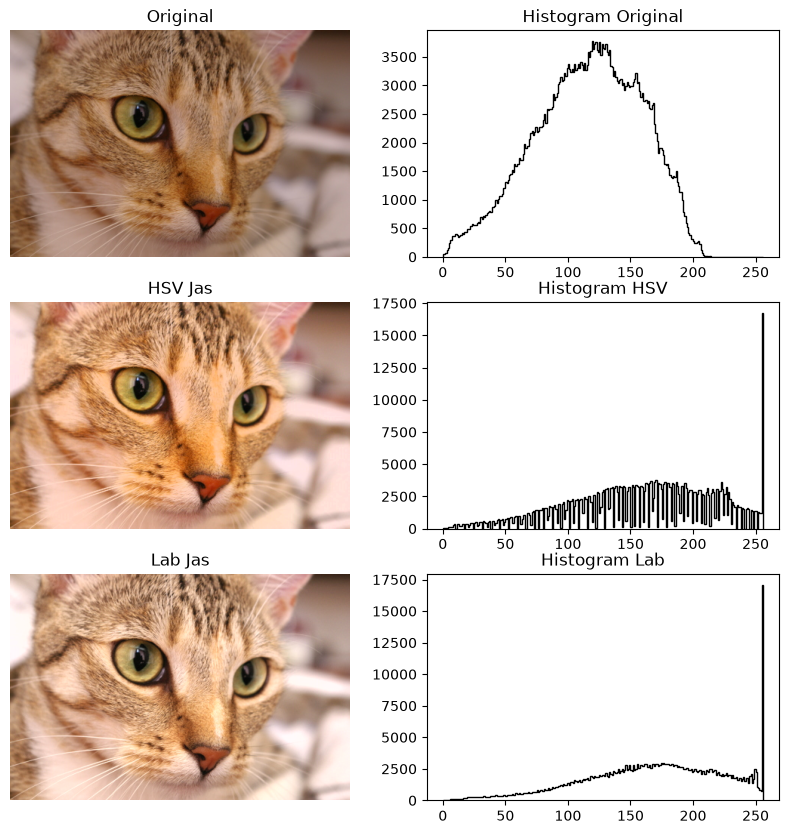

In [25]:
image = sk.data.cat()
bins = 256  # pre histogram

image_float = image / 255.0 # normalizacia pre HSV a Lab konverziu

# Premena na HSV - Hue, Saturation, value
image_hsv = sk.color.rgb2hsv(image_float)
image_hsv[:, :, 2] = np.clip(image_hsv[:, :, 2] * 1.4, 0, 1)
img_hsv_rgb = sk.color.hsv2rgb(image_hsv)  # prevod späť do RGB

# Premena na Lab - Luminance, a, b
img_lab = sk.color.rgb2lab(image_float)
img_lab[:, :, 0] = np.clip(img_lab[:, :, 0] * 1.4, 0, 100)
img_lab_rgb = sk.color.lab2rgb(img_lab)    # prevod späť do RGB

# Vytvorenie grafu: 1 riadok, 2 stĺpce
fig, axs = plt.subplots(3, 2, figsize=(10, 10))

# 1. RIADOK: Pôvodný obrázok
axs[0, 0].imshow(image)
axs[0, 0].set_title("Original")
axs[0, 0].axis("off")

axs[0, 1].hist(image.ravel(), bins=bins, range=(0, 256), histtype='step', color='black')
axs[0, 1].set_title("Histogram Original")

# 2. RIADOK: HSV
axs[1, 0].imshow(img_hsv_rgb)
axs[1, 0].set_title("HSV Jas")
axs[1, 0].axis("off")

axs[1, 1].hist((img_hsv_rgb * 255).ravel(), bins=bins, range=(0, 256), histtype='step', color='black')
axs[1, 1].set_title("Histogram HSV")

# 3. RIADOK: Lab
axs[2, 0].imshow(img_lab_rgb)
axs[2, 0].set_title("Lab Jas")
axs[2, 0].axis("off")

axs[2, 1].hist((img_lab_rgb * 255).ravel(), bins=bins, range=(0, 256), histtype='step', color='black')
axs[2, 1].set_title("Histogram Lab")

plt.show()